# Sprint 1 — Pre-processing
**Case Study I — CRM → Billing configuration prediction**

Goal of this sprint: turn the raw `train.csv` / `test.csv` files into a clean, modeling-ready
dataset, and understand the structure of the problem well enough to design Sprint 2 (modeling).

Submission: this notebook, due **22/09/2026 23:59** (40% of the final grade).

Problem recap: given 745 binary CRM configuration columns, predict the 731 binary BILLING
configuration columns (a large multi-label classification problem, evaluated with Exact
Matching Ratio — every label in a row must be correct for that row to count).

## 0. Setup

In [26]:
import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

DATA_DIR = '../data'
DERIVED_DIR = f'{DATA_DIR}/derived'
os.makedirs(DERIVED_DIR, exist_ok=True)


## 1. Load the data

The raw files are large (train.csv ~560MB, test.csv ~148MB). Everything except `MSISDN` is
binary (0/1), so we load as `int8` / `uint8` to keep memory manageable — this alone cuts
memory use by roughly 8x vs. the pandas default `int64`.

In [27]:
# Peek at the header first to build a dtype map without loading everything as int64 first
header = pd.read_csv(f'{DATA_DIR}/train.csv', nrows=0).columns.tolist()
crm_cols = [c for c in header if c.startswith('CRM')]
bil_cols = [c for c in header if c.startswith('BIL')]
print(f'{len(crm_cols)} CRM columns, {len(bil_cols)} BIL columns, {len(header)} total')

dtype_map = {c: 'int8' for c in crm_cols + bil_cols}
dtype_map['MSISDN'] = str

train = pd.read_csv(f'{DATA_DIR}/train.csv', dtype=dtype_map)
print('train shape:', train.shape)
train.head()

745 CRM columns, 731 BIL columns, 1477 total
train shape: (187442, 1477)


,MSISDN,CRM_BUSINESS_LINE_ORIG_Mobile,CRM_1519_PACK,CRM_1521_PACK,CRM_1522_PACK,CRM_1523_PACK,CRM_1524_PACK,CRM_1525_PACK,CRM_1526_PACK,CRM_1527_PACK,CRM_1528_PACK,CRM_1529_PACK,CRM_1530_PACK,CRM_1532_PACK,CRM_1533_PACK,CRM_1534_PACK,CRM_1536_PACK,CRM_1537_PACK,CRM_1538_PACK,CRM_1539_PACK,CRM_1540_PACK,CRM_1541_PACK,CRM_1542_PACK,CRM_1543_PACK,CRM_1545_PACK,...,BIL_4449_PACK,BIL_4450_PACK,BIL_4451_PACK,BIL_4452_PACK,BIL_4454_PACK,BIL_4455_PACK,BIL_4456_PACK,BIL_4457_PACK,BIL_4458_PACK,BIL_4459_PACK,BIL_4460_PACK,BIL_4461_PACK,BIL_4462_PACK,BIL_4463_PACK,BIL_4464_PACK,BIL_4465_PACK,BIL_4466_PACK,BIL_4467_PACK,BIL_4468_PACK,BIL_4504_PACK,BIL_4506_PACK,BIL_4507_PACK,BIL_4508_PACK,BIL_4509_PACK,BIL_4510_PACK
0,4f1b9e575ac7ea93b4a978b3095d7ee1,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,01908281632545a2fc22d4a6365f2b27,1,0,0,0,0,0,0,0,0,0,1,0,1,1,1,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,f6f0c782716d8928928407c4e426be25,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,a543952f2405c440fc40f85e8adfdfd6,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,63e3cdf2eff067ce9af9f9f8530b16eb,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [28]:
test_dtype_map = {c: 'int8' for c in crm_cols}
test_dtype_map['MSISDN'] = str
test = pd.read_csv(f'{DATA_DIR}/test.csv', dtype=test_dtype_map)
print('test shape:', test.shape)
test.head()

test shape: (97100, 746)


,MSISDN,CRM_BUSINESS_LINE_ORIG_Mobile,CRM_1519_PACK,CRM_1521_PACK,CRM_1522_PACK,CRM_1523_PACK,CRM_1524_PACK,CRM_1525_PACK,CRM_1526_PACK,CRM_1527_PACK,CRM_1528_PACK,CRM_1529_PACK,CRM_1530_PACK,CRM_1532_PACK,CRM_1533_PACK,CRM_1534_PACK,CRM_1536_PACK,CRM_1537_PACK,CRM_1538_PACK,CRM_1539_PACK,CRM_1540_PACK,CRM_1541_PACK,CRM_1542_PACK,CRM_1543_PACK,CRM_1545_PACK,...,CRM_2370_PACK,CRM_2371_PACK,CRM_2372_PACK,CRM_2373_PACK,CRM_2374_PACK,CRM_2375_PACK,CRM_2376_PACK,CRM_2377_PACK,CRM_2378_PACK,CRM_2379_PACK,CRM_2380_PACK,CRM_2381_PACK,CRM_2382_PACK,CRM_2383_PACK,CRM_2385_PACK,CRM_2387_PACK,CRM_2388_PACK,CRM_2389_PACK,CRM_2391_PACK,CRM_2392_PACK,CRM_2394_PACK,CRM_2395_PACK,CRM_2396_PACK,CRM_2397_PACK,CRM_2398_PACK
0,db67b03cf9fb8ea96077cd34c7a28139,1,0,1,1,1,0,0,1,1,1,1,0,1,1,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2ac0d310d5cf1a96587af614d37b8b54,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,a8f289fbd263794ac74059a18c1d10a5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5a53a1c85ccc7e794c90c75b75b8d3cb,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,484b400226b8894377e12204219283fc,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Basic sanity checks

- Any missing values?
- Any duplicate MSISDN?
- How sparse are the CRM / BIL configurations (mean activation rate per column)?

In [29]:
print('Missing values in train:', train.isna().sum().sum())
print('Missing values in test:', test.isna().sum().sum())
print('Duplicate MSISDN in train:', train['MSISDN'].duplicated().sum())
print('Duplicate MSISDN in test:', test['MSISDN'].duplicated().sum())

print('\nMean activation rate, CRM columns:', train[crm_cols].mean().mean().round(4))
print('Mean activation rate, BIL columns:', train[bil_cols].mean().mean().round(4))

pd.DataFrame([{
    'missing_values_train': int(train.isna().sum().sum()),
    'missing_values_test': int(test.isna().sum().sum()),
    'duplicate_msisdn_train': int(train['MSISDN'].duplicated().sum()),
    'duplicate_msisdn_test': int(test['MSISDN'].duplicated().sum()),
    'mean_crm_activation_rate': round(float(train[crm_cols].mean().mean()), 4),
    'mean_bil_activation_rate': round(float(train[bil_cols].mean().mean()), 4),
}]).to_csv(f'{DERIVED_DIR}/basic_sanity.csv', index=False)

Missing values in train: 0
Missing values in test: 0
Duplicate MSISDN in train: 0
Duplicate MSISDN in test: 0

Mean activation rate, CRM columns: 0.0205
Mean activation rate, BIL columns: 0.0201


In [30]:
crm_var = train[crm_cols].nunique()
bil_var = train[bil_cols].nunique()

constant_crm = crm_var[crm_var <= 1].index.tolist()
constant_bil = bil_var[bil_var <= 1].index.tolist()

print(f'Constant (zero-variance) CRM columns: {len(constant_crm)} / {len(crm_cols)}')
print(f'Constant (zero-variance) BIL columns: {len(constant_bil)} / {len(bil_cols)}')

pd.DataFrame(
    [{'system': 'CRM', 'column': c} for c in constant_crm]
    + [{'system': 'BIL', 'column': c} for c in constant_bil]
).to_csv(f'{DERIVED_DIR}/constant_columns.csv', index=False)

Constant (zero-variance) CRM columns: 2 / 745
Constant (zero-variance) BIL columns: 0 / 731


## 2b. Referential integrity checks

CRM and BIL are already columns of the same row per `MSISDN` (not separate tables to join),
so there's no classic "orphaned foreign key" risk here. The actual risks in this format are
schema drift between train/test and stray non-binary values slipping in — both would silently
break the modeling pipeline downstream, so these are hard asserts, not just diagnostics.

In [31]:
from src.preprocessing import referential_integrity_checks

integrity = referential_integrity_checks(train, test, crm_cols, bil_cols)
print('All hard integrity checks passed (would have raised AssertionError otherwise):')
for k, v in integrity.items():
    print(f'  {k}: {v}')

pd.DataFrame([integrity]).to_csv(f'{DERIVED_DIR}/referential_integrity.csv', index=False)

All hard integrity checks passed (would have raised AssertionError otherwise):
  columns_match: True
  train_binary_only: True
  test_binary_only: True
  train_nulls: 0
  test_nulls: 0
  n_duplicate_msisdn_train: 0
  n_duplicate_msisdn_test: 0
  n_msisdn_overlap_train_test: 0


## 3. The CRM → BILLING relationship

The brief says the mapping can be many-to-one (different CRM configs → same BILLING config),
**and** that the training data contains provisioning errors — i.e. for some identical CRM
configs, different BILLING configs appear. Let's measure this directly, since it shapes how
noisy Sprint 2's target really is.

In [32]:
# Encode each row's CRM config and BIL config as a single string key so we can group on it
crm_key = train[crm_cols].astype(str).agg(''.join, axis=1)
bil_key = train[bil_cols].astype(str).agg(''.join, axis=1)

n_unique_crm = crm_key.nunique()
n_unique_bil = bil_key.nunique()
print(f'Unique CRM configs: {n_unique_crm} ({n_unique_crm/len(train):.1%} of rows)')
print(f'Unique BIL configs: {n_unique_bil} ({n_unique_bil/len(train):.1%} of rows)')

pairs = pd.DataFrame({'crm': crm_key, 'bil': bil_key})
ambiguous = pairs.groupby('crm')['bil'].nunique()
n_ambiguous = (ambiguous > 1).sum()
print(f'CRM configs mapping to >1 distinct BIL config (likely provisioning errors): '
      f'{n_ambiguous} / {len(ambiguous)} unique CRM configs '
      f'({n_ambiguous/len(ambiguous):.1%})')

pd.DataFrame([{
    'n_train_rows': len(train),
    'n_unique_crm_configs': int(n_unique_crm),
    'n_unique_bil_configs': int(n_unique_bil),
    'n_ambiguous_crm_groups': int(n_ambiguous),
    'n_total_crm_groups': int(len(ambiguous)),
    'pct_ambiguous_crm_groups': round(float(n_ambiguous / len(ambiguous)), 6),
}]).to_csv(f'{DERIVED_DIR}/crm_bil_relationship_summary.csv', index=False)

Unique CRM configs: 67434 (36.0% of rows)
Unique BIL configs: 67201 (35.9% of rows)
CRM configs mapping to >1 distinct BIL config (likely provisioning errors): 617 / 67434 unique CRM configs (0.9%)


## 4. Column taxonomy: one-hot categoricals vs. numeric PACK features

Column names reveal two families: a handful of one-hot encoded categorical blocks
(`BUSINESS_LINE`, `SUBSCRIBER_TYPE`, `SUBSCRIBER_STATUS`) and hundreds of binary `_<id>_PACK`
flags. Worth splitting these out because they behave very differently — categoricals are
mutually exclusive within their group and dense; packs are sparse and largely independent —
and because it's worth checking whether the numeric PACK ids form a shared vocabulary between
CRM and BILLING (spoiler: they don't, which rules out a naming-based lookup shortcut).

In [33]:
import re

def split_taxonomy(cols, prefix):
    packs = [c for c in cols if re.match(rf'^{prefix}_\d+_PACK$', c)]
    meta = [c for c in cols if c not in packs]
    return packs, meta

crm_packs, crm_meta = split_taxonomy(crm_cols, 'CRM')
bil_packs, bil_meta = split_taxonomy(bil_cols, 'BIL')

print(f'CRM: {len(crm_packs)} pack columns, {len(crm_meta)} categorical (one-hot) columns')
print(f'BIL: {len(bil_packs)} pack columns, {len(bil_meta)} categorical (one-hot) columns')

def onehot_groups(meta_cols):
    groups = {}
    for c in meta_cols:
        base = c.rsplit('_', 1)[0]
        groups.setdefault(base, []).append(c)
    return groups

onehot_group_rows = []
for label, meta_cols in [('CRM', crm_meta), ('BIL', bil_meta)]:
    print(f'\n{label} categorical groups:')
    for base, cols in onehot_groups(meta_cols).items():
        row_sums = train[cols].sum(axis=1)
        pct_1 = (row_sums == 1).mean()
        pct_0 = (row_sums == 0).mean()
        print(f'  {base}: {len(cols)} categories, rows summing to exactly 1: '
              f'{pct_1:.1%}, to 0: {pct_0:.1%}')
        onehot_group_rows.append({
            'system': label, 'group': base, 'n_categories': len(cols),
            'pct_rows_sum_to_1': round(float(pct_1), 6),
            'pct_rows_sum_to_0': round(float(pct_0), 6),
        })

# confirm there's no shared numeric-id vocabulary between CRM and BIL packs
crm_ids = {re.match(r'CRM_(\d+)_PACK$', c).group(1) for c in crm_packs}
bil_ids = {re.match(r'BIL_(\d+)_PACK$', c).group(1) for c in bil_packs}
print(f'\nOverlap between CRM and BIL numeric pack ids: {len(crm_ids & bil_ids)} / '
      f'{len(crm_ids)} CRM ids, {len(bil_ids)} BIL ids')

pd.DataFrame([{
    'n_crm_packs': len(crm_packs), 'n_crm_onehot': len(crm_meta),
    'n_bil_packs': len(bil_packs), 'n_bil_onehot': len(bil_meta),
    'n_shared_pack_ids': len(crm_ids & bil_ids),
}]).to_csv(f'{DERIVED_DIR}/taxonomy_summary.csv', index=False)
pd.DataFrame(onehot_group_rows).to_csv(f'{DERIVED_DIR}/onehot_groups.csv', index=False)

CRM: 730 pack columns, 15 categorical (one-hot) columns
BIL: 717 pack columns, 14 categorical (one-hot) columns

CRM categorical groups:
  CRM_BUSINESS_LINE_ORIG: 1 categories, rows summing to exactly 1: 99.9%, to 0: 0.1%
  CRM_SUBSCRIBER_TYPE_ORIG: 3 categories, rows summing to exactly 1: 99.7%, to 0: 0.1%
  CRM_SUBSCRIBER_STATUS_ORIG: 6 categories, rows summing to exactly 1: 82.5%, to 0: 17.1%
  CRM_SUBSCRIBER_STATUS_ORIG_Block_1: 1 categories, rows summing to exactly 1: 11.0%, to 0: 89.0%
  CRM_SUBSCRIBER_STATUS_ORIG_Block_2: 1 categories, rows summing to exactly 1: 6.0%, to 0: 94.0%
  CRM_SUBSCRIBER_STATUS_ORIG_Pre: 3 categories, rows summing to exactly 1: 0.6%, to 0: 99.4%

BIL categorical groups:
  BIL_BUSINESS_LINE_ORIG: 1 categories, rows summing to exactly 1: 99.9%, to 0: 0.1%
  BIL_SUBSCRIBER_STATUS_ORIG: 5 categories, rows summing to exactly 1: 82.7%, to 0: 16.9%
  BIL_SUBSCRIBER_STATUS_ORIG_Block_1: 1 categories, rows summing to exactly 1: 11.1%, to 0: 88.9%
  BIL_SUBSCRIBE

## 5. Activation-rate distributions

How rare is each pack, and how many packs does a typical customer have active? This matters
for Sprint 2: extremely rare BIL labels (positive in only a handful of rows) will be very hard
to learn and may need to be grouped, thresholded, or evaluated separately from the rest.

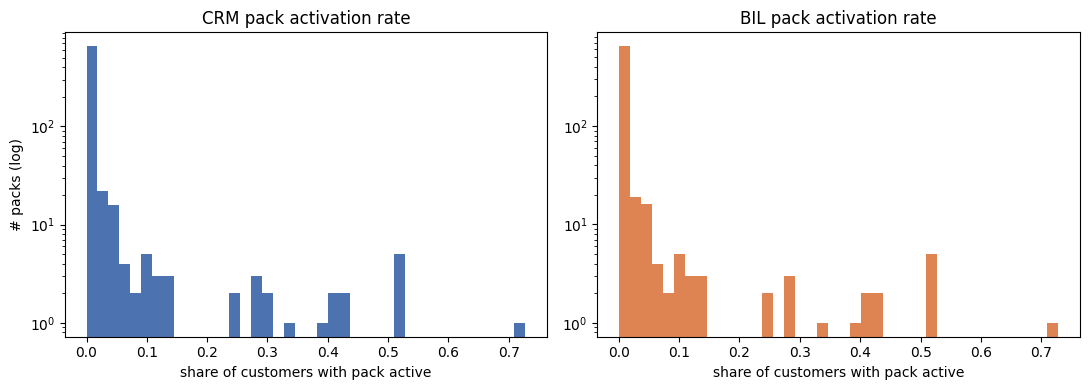

CRM packs active in <0.1% of rows: 16 / 730
BIL packs active in <0.1% of rows: 10 / 717

Top 10 most common CRM packs:
 CRM_1537_PACK    0.727409
CRM_1542_PACK    0.520918
CRM_1533_PACK    0.520908
CRM_1529_PACK    0.520033
CRM_1541_PACK    0.519009
CRM_1532_PACK    0.514623
CRM_2076_PACK    0.428463
CRM_2077_PACK    0.423219
CRM_2087_PACK    0.417414
CRM_2088_PACK    0.402098
dtype: float64

Top 10 most common BIL packs:
 BIL_3748_PACK    0.727542
BIL_3933_PACK    0.520897
BIL_3934_PACK    0.520844
BIL_3921_PACK    0.520017
BIL_3927_PACK    0.519057
BIL_3922_PACK    0.514426
BIL_3749_PACK    0.428202
BIL_3750_PACK    0.422792
BIL_3745_PACK    0.417116
BIL_3744_PACK    0.401751
dtype: float64


In [34]:
crm_rate = train[crm_packs].mean().sort_values(ascending=False)
bil_rate = train[bil_packs].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(crm_rate, bins=40, color='#4C72B0')
axes[0].set_title('CRM pack activation rate')
axes[0].set_xlabel('share of customers with pack active')
axes[0].set_ylabel('# packs (log)')
axes[0].set_yscale('log')

axes[1].hist(bil_rate, bins=40, color='#DD8452')
axes[1].set_title('BIL pack activation rate')
axes[1].set_xlabel('share of customers with pack active')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

print('CRM packs active in <0.1% of rows:', (crm_rate < 0.001).sum(), '/', len(crm_rate))
print('BIL packs active in <0.1% of rows:', (bil_rate < 0.001).sum(), '/', len(bil_rate))
print('\nTop 10 most common CRM packs:\n', crm_rate.head(10))
print('\nTop 10 most common BIL packs:\n', bil_rate.head(10))

pd.concat([
    crm_rate.rename('activation_rate').reset_index().rename(columns={'index': 'pack'}).assign(system='CRM'),
    bil_rate.rename('activation_rate').reset_index().rename(columns={'index': 'pack'}).assign(system='BIL'),
]).to_csv(f'{DERIVED_DIR}/pack_activation_rates.csv', index=False)

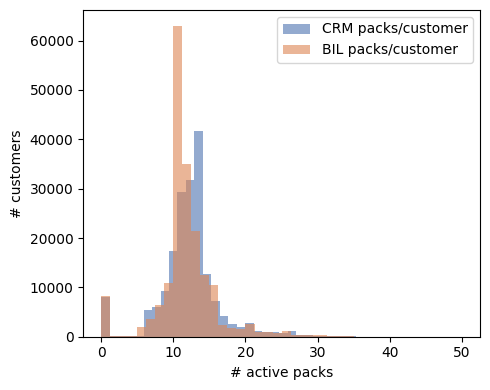

count    187442.000000
mean         12.283890
std           4.358965
min           0.000000
25%          11.000000
50%          12.000000
75%          14.000000
max          47.000000
dtype: float64
count    187442.000000
mean         11.677207
std           4.066598
min           0.000000
25%          10.000000
50%          11.000000
75%          13.000000
max          50.000000
dtype: float64

Correlation between #CRM packs and #BIL packs per customer: 0.932


In [35]:
crm_count = train[crm_packs].sum(axis=1)
bil_count = train[bil_packs].sum(axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(crm_count, bins=40, alpha=0.6, label='CRM packs/customer', color='#4C72B0')
ax.hist(bil_count, bins=40, alpha=0.6, label='BIL packs/customer', color='#DD8452')
ax.set_xlabel('# active packs')
ax.set_ylabel('# customers')
ax.legend()
plt.tight_layout()
plt.show()

print(crm_count.describe())
print(bil_count.describe())
print(f'\nCorrelation between #CRM packs and #BIL packs per customer: {crm_count.corr(bil_count):.3f}')

pd.DataFrame({
    'crm_packs_per_customer': crm_count.describe(),
    'bil_packs_per_customer': bil_count.describe(),
}).assign(
    crm_bil_pack_count_corr=round(float(crm_count.corr(bil_count)), 4)
).to_csv(f'{DERIVED_DIR}/pack_count_stats.csv')

## 5b. Outlier detection on pack-count distributions (IQR)

`crm_count`/`bil_count` above are right-skewed and long-tailed, so Tukey's IQR fences
(`[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`) are used instead of z-scores — z-scores assume rough
symmetry and would over-flag the tail of a skewed distribution using a mean/std that the
tail itself distorts.

**Flag, don't remove or cap.** A customer with an unusually high or low pack count isn't a
measurement error — they're a real row that still needs a correct BIL prediction in test.
Capping or dropping them would strip exactly the hard cases out of training with no evidence
anything is actually wrong, which would likely *hurt* held-out EMR rather than help it. So
this is a diagnostic for the report (and a candidate stratification signal for the Sprint 2
train/validation split), not a filter applied to `train_clean`/`test_clean`.

In [36]:
from src.preprocessing import flag_count_outliers

crm_is_outlier, crm_lo, crm_hi = flag_count_outliers(crm_count)
bil_is_outlier, bil_lo, bil_hi = flag_count_outliers(bil_count)
outlier_mask = crm_is_outlier | bil_is_outlier

print(f'CRM pack-count IQR fences: [{crm_lo:.1f}, {crm_hi:.1f}] -> {crm_is_outlier.sum()} flagged rows')
print(f'BIL pack-count IQR fences: [{bil_lo:.1f}, {bil_hi:.1f}] -> {bil_is_outlier.sum()} flagged rows')
print(f'Union (either CRM or BIL flagged): {outlier_mask.sum()} / {len(train)} rows '
      f'({outlier_mask.mean():.2%})')

pack_count_outliers = pd.DataFrame({
    'MSISDN': train.loc[outlier_mask, 'MSISDN'],
    'n_crm_packs': crm_count[outlier_mask],
    'n_bil_packs': bil_count[outlier_mask],
    'crm_outlier': crm_is_outlier[outlier_mask],
    'bil_outlier': bil_is_outlier[outlier_mask],
})
pack_count_outliers.to_csv(f'{DERIVED_DIR}/pack_count_outliers.csv', index=False)
pack_count_outliers.head()

CRM pack-count IQR fences: [6.5, 18.5] -> 21673 flagged rows
BIL pack-count IQR fences: [5.5, 17.5] -> 19928 flagged rows
Union (either CRM or BIL flagged): 24253 / 187442 rows (12.94%)


,MSISDN,n_crm_packs,n_bil_packs,crm_outlier,bil_outlier
3,a543952f2405c440fc40f85e8adfdfd6,22,14,True,False
21,3bd71759181041e39304827d67870716,24,16,True,False
36,b447a2ae3036f1f4d8a45077a8c2264a,15,26,False,True
46,b07244a41b129847a8ef6265f531685d,17,18,False,True
100,da98d61522e313f8339c88e8e19abeb3,31,17,True,False


## 5c. Label imbalance audit

Bucketing each column's activation rate from ultra-rare to dense. This matters specifically
*because* the metric is EMR: a naive classifier that predicts all-zero for a rare BIL pack
still scores well on per-label accuracy, but under EMR that one wrong bit fails the entire
row — so the size of the rare-label tail is a direct read on how much headroom there is to
lose in Sprint 2 just from mishandling a handful of sparse labels.

In [37]:
from src.preprocessing import label_imbalance_report

crm_imbalance = label_imbalance_report(train[crm_cols].mean())
bil_imbalance = label_imbalance_report(train[bil_cols].mean())

print('CRM columns:')
display(crm_imbalance)

print('\nBIL columns (the actual prediction targets):')
display(bil_imbalance)

pd.concat([
    crm_imbalance.assign(system='CRM'),
    bil_imbalance.assign(system='BIL'),
]).to_csv(f'{DERIVED_DIR}/label_imbalance.csv', index=False)

CRM columns:


,imbalance_tier,n_columns
0,ultra_rare(<0.1%),16
1,rare(0.1-1%),613
2,uncommon(1-10%),82
3,common(10-50%),25
4,dense(>=50%),9



BIL columns (the actual prediction targets):


,imbalance_tier,n_columns
0,ultra_rare(<0.1%),10
1,rare(0.1-1%),607
2,uncommon(1-10%),82
3,common(10-50%),23
4,dense(>=50%),9


## 6. Correlation structure

Three questions:
1. Are CRM packs redundant with each other (near-duplicate flags)?
2. Same question for BIL packs.
3. Which BIL packs have a strong single-feature CRM predictor, and which don't — i.e. which
   labels will Sprint 2's model likely struggle with?

All correlation matrices below are computed on a random subsample of rows (30k). This is a
directional EDA read, not a precise estimate, and it keeps the pairwise computation
(745×745, 731×731, 745×731) fast.

In [38]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(train), size=30_000, replace=False)
crm_sample = train.loc[sample_idx, crm_packs]
bil_sample = train.loc[sample_idx, bil_packs]

def pearson_corr_matrix(A, B):
    """Correlation matrix between columns of A and columns of B (0/1 cols, same rows)."""
    A = A.astype(np.float32).to_numpy()
    B = B.astype(np.float32).to_numpy()
    n = A.shape[0]
    A = A - A.mean(axis=0)
    B = B - B.mean(axis=0)
    cov = (A.T @ B) / n
    denom = np.outer(A.std(axis=0), B.std(axis=0))
    denom[denom == 0] = np.nan  # constant columns -> undefined correlation
    return cov / denom

def top_pairs_symmetric(corr, names, top_n=15):
    """Top |corr| pairs from a symmetric matrix (upper triangle only, no self-pairs)."""
    i_idx, j_idx = np.triu_indices(len(names), k=1)
    vals = corr[i_idx, j_idx]
    mask = ~np.isnan(vals)
    df = pd.DataFrame({'col_a': np.array(names)[i_idx[mask]],
                        'col_b': np.array(names)[j_idx[mask]],
                        'corr': vals[mask]})
    return df.reindex(df['corr'].abs().sort_values(ascending=False).index).head(top_n)

def top_pairs_cross(corr, row_names, col_names, top_n=15):
    """Top |corr| pairs from a full (non-symmetric) row x col matrix."""
    i_idx, j_idx = np.indices(corr.shape)
    vals = corr.ravel()
    mask = ~np.isnan(vals)
    df = pd.DataFrame({'crm': np.array(row_names)[i_idx.ravel()[mask]],
                        'bil': np.array(col_names)[j_idx.ravel()[mask]],
                        'corr': vals[mask]})
    return df.reindex(df['corr'].abs().sort_values(ascending=False).index).head(top_n)

crm_corr = pearson_corr_matrix(crm_sample, crm_sample)
bil_corr = pearson_corr_matrix(bil_sample, bil_sample)
cross_corr = pearson_corr_matrix(crm_sample, bil_sample)  # rows=CRM packs, cols=BIL packs

top_crm_pairs = top_pairs_symmetric(crm_corr, crm_packs)
top_bil_pairs = top_pairs_symmetric(bil_corr, bil_packs)
top_cross_pairs = top_pairs_cross(cross_corr, crm_packs, bil_packs)

print('Most correlated CRM pack pairs (near-duplicate / always-bundled features):')
display(top_crm_pairs)

print('\nMost correlated BIL pack pairs:')
display(top_bil_pairs)

print('\nMost correlated CRM <-> BIL pack pairs (strongest single-feature predictors):')
display(top_cross_pairs)

pd.concat([
    top_crm_pairs.assign(pair_type='crm-crm'),
    top_bil_pairs.assign(pair_type='bil-bil'),
    top_cross_pairs.rename(columns={'crm': 'col_a', 'bil': 'col_b'}).assign(pair_type='crm-bil'),
]).to_csv(f'{DERIVED_DIR}/eda_sample_correlated_pairs.csv', index=False)

Most correlated CRM pack pairs (near-duplicate / always-bundled features):


,col_a,col_b,corr
8665,CRM_1533_PACK,CRM_1542_PACK,0.996055
10089,CRM_1536_PACK,CRM_1539_PACK,0.994707
6517,CRM_1529_PACK,CRM_1542_PACK,0.994389
6509,CRM_1529_PACK,CRM_1533_PACK,0.993791
13642,CRM_1541_PACK,CRM_1542_PACK,0.992259
8664,CRM_1533_PACK,CRM_1541_PACK,0.991930
6516,CRM_1529_PACK,CRM_1541_PACK,0.990523
7950,CRM_1532_PACK,CRM_1542_PACK,0.982187
7942,CRM_1532_PACK,CRM_1533_PACK,0.981445
6508,CRM_1529_PACK,CRM_1532_PACK,0.980573



Most correlated BIL pack pairs:


,col_a,col_b,corr
56658,BIL_3933_PACK,BIL_3934_PACK,0.996459
49007,BIL_3921_PACK,BIL_3933_PACK,0.994858
49008,BIL_3921_PACK,BIL_3934_PACK,0.994788
52850,BIL_3927_PACK,BIL_3933_PACK,0.992261
52851,BIL_3927_PACK,BIL_3934_PACK,0.992194
49001,BIL_3921_PACK,BIL_3927_PACK,0.990982
49650,BIL_3922_PACK,BIL_3933_PACK,0.982803
49651,BIL_3922_PACK,BIL_3934_PACK,0.982718
48996,BIL_3921_PACK,BIL_3922_PACK,0.981110
49644,BIL_3922_PACK,BIL_3927_PACK,0.978209



Most correlated CRM <-> BIL pack pairs (strongest single-feature predictors):


,crm,bil,corr
14424,CRM_1542_PACK,BIL_3933_PACK,0.996728
14425,CRM_1542_PACK,BIL_3934_PACK,0.996393
8689,CRM_1533_PACK,BIL_3934_PACK,0.996322
8688,CRM_1533_PACK,BIL_3933_PACK,0.995856
6525,CRM_1529_PACK,BIL_3921_PACK,0.995723
103971,CRM_2088_PACK,BIL_3744_PACK,0.995691
106117,CRM_2091_PACK,BIL_3739_PACK,0.995671
7960,CRM_1532_PACK,BIL_3922_PACK,0.995326
103255,CRM_2087_PACK,BIL_3745_PACK,0.995262
13701,CRM_1541_PACK,BIL_3927_PACK,0.995258


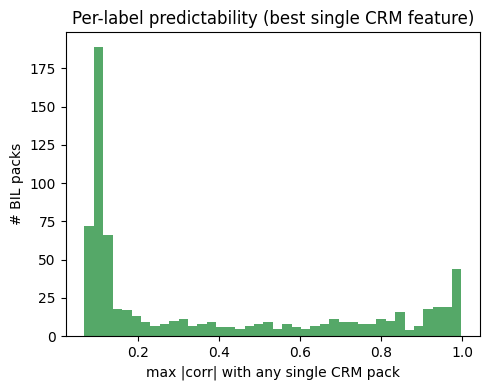

BIL packs with no CRM pack correlated above 0.3: 409 / 717 (57.0%) — these are the labels to watch in Sprint 2


In [39]:
# For each BIL pack, how strong is its *best* single CRM predictor? Low values flag labels
# that will need real multivariate signal (or will just stay hard) in Sprint 2.
max_abs_corr_per_bil = np.nanmax(np.abs(cross_corr), axis=0)

plt.figure(figsize=(5, 4))
plt.hist(max_abs_corr_per_bil, bins=40, color='#55A868')
plt.xlabel('max |corr| with any single CRM pack')
plt.ylabel('# BIL packs')
plt.title('Per-label predictability (best single CRM feature)')
plt.tight_layout()
plt.show()

weak = (max_abs_corr_per_bil < 0.3).sum()
print(f'BIL packs with no CRM pack correlated above 0.3: {weak} / {len(bil_packs)} '
      f'({weak/len(bil_packs):.1%}) — these are the labels to watch in Sprint 2')

pd.DataFrame({
    'bil_pack': bil_packs,
    'max_abs_corr_with_any_crm_pack': max_abs_corr_per_bil,
}).to_csv(f'{DERIVED_DIR}/bil_predictability_eda_sample.csv', index=False)

## 7. Clustering

Two angles: (a) cluster **packs** by co-activation to find bundles — features that travel
together, useful for dimensionality reduction / feature engineering in Sprint 2 — and
(b) cluster **customers** by their CRM configuration to see whether there are a handful of
dominant profiles versus a continuous spread, and whether those profiles differ in billing
complexity.

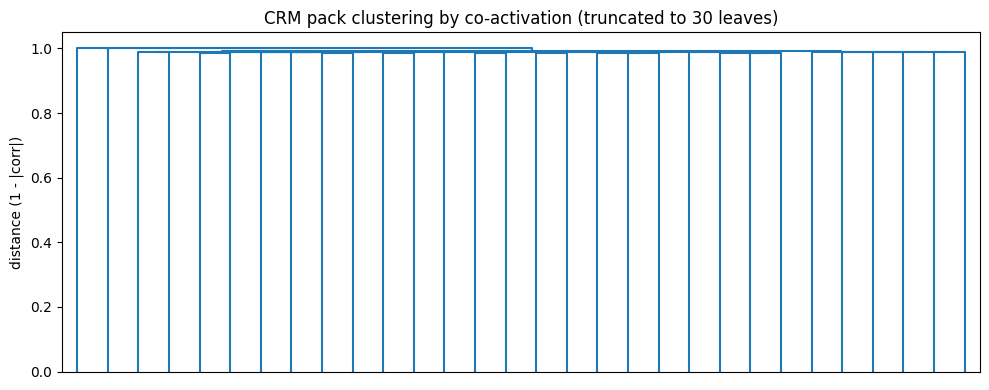

In [40]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# correlation distance: 1 - |corr|, so uncorrelated packs end up far apart
crm_corr_clean = np.nan_to_num(crm_corr, nan=0.0)
np.fill_diagonal(crm_corr_clean, 1.0)
dist = 1 - np.abs(crm_corr_clean)
dist = (dist + dist.T) / 2  # enforce exact symmetry for squareform
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)

Z = linkage(condensed, method='average')

plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=30, no_labels=True)
plt.title('CRM pack clustering by co-activation (truncated to 30 leaves)')
plt.ylabel('distance (1 - |corr|)')
plt.tight_layout()
plt.show()

Variance explained by 20 SVD components: 68.9%


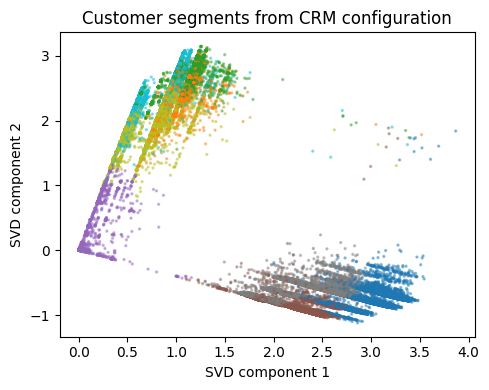

,size,avg_crm_packs,avg_bil_packs,n_unique_bil_configs
cluster,,,,
0,41980,14.7,12.6,18531
1,16034,10.7,10.7,2667
2,24301,12.0,12.0,4190
3,12024,3.2,3.2,1427
4,17628,15.1,13.5,9431
5,38028,13.1,13.1,19792
6,24098,10.5,10.5,6644
7,13349,12.6,12.6,4992


In [41]:
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from scipy.sparse import csr_matrix

X = csr_matrix(train[crm_packs].to_numpy(dtype=np.float32))
svd = TruncatedSVD(n_components=20, random_state=42)
X_svd = svd.fit_transform(X)
print(f'Variance explained by 20 SVD components: {svd.explained_variance_ratio_.sum():.1%}')

kmeans = MiniBatchKMeans(n_clusters=8, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_svd)

plt.figure(figsize=(5, 4))
plt.scatter(X_svd[:, 0], X_svd[:, 1], c=clusters, cmap='tab10', s=2, alpha=0.4)
plt.xlabel('SVD component 1')
plt.ylabel('SVD component 2')
plt.title('Customer segments from CRM configuration')
plt.tight_layout()
plt.show()

profile = pd.DataFrame({
    'cluster': clusters,
    'n_crm_packs': crm_count.to_numpy(),
    'n_bil_packs': bil_count.to_numpy(),
    'bil_key': bil_key.to_numpy(),
})
summary = profile.groupby('cluster').agg(
    size=('cluster', 'size'),
    avg_crm_packs=('n_crm_packs', 'mean'),
    avg_bil_packs=('n_bil_packs', 'mean'),
    n_unique_bil_configs=('bil_key', 'nunique'),
).round(1)
display(summary)

summary.assign(
    svd_variance_explained=round(float(svd.explained_variance_ratio_.sum()), 4)
).to_csv(f'{DERIVED_DIR}/customer_segments.csv')

## 8. Aggregation by billing configuration (long tail)

How much of the customer base is covered by a small number of common configurations? If a
small set of BIL (or CRM) configs covers most customers, Sprint 2 could partly frame this as
"classify into a known bundle, handle the long tail separately" rather than as 731 fully
independent binary predictions. Also worth checking whether billing complexity varies by
customer segment (subscriber type, business line).

Top 15 most common BIL configs:
 rank    share  n_active_packs
    1 0.043331               4
    2 0.014554              14
    3 0.014026              14
    4 0.009166              13
    5 0.007778              14
    6 0.007725              13
    7 0.007208               9
    8 0.006583              13
    9 0.006514              10
   10 0.006274              13
   11 0.004924              12
   12 0.004689              11
   13 0.004364              15
   14 0.003879              14
   15 0.003772              15


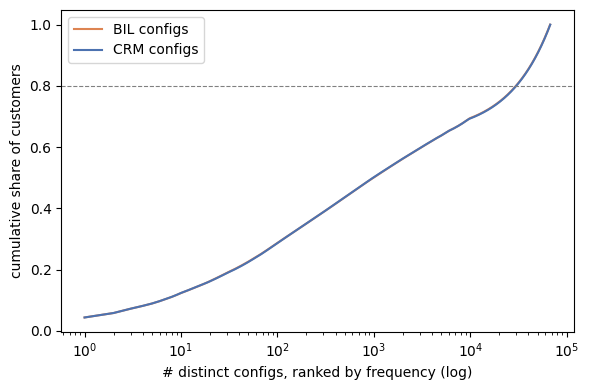


# distinct BIL configs needed to cover 80% of customers: 29713 (out of 67201 unique configs)


In [42]:
bil_counts = pairs['bil'].value_counts()
crm_counts = pairs['crm'].value_counts()

# the raw config is a 731-char bitstring — not printable, so summarize each top config instead
bil_top = (bil_counts.head(15) / len(train)).reset_index()
bil_top.columns = ['bil_config', 'share']
bil_top.insert(0, 'rank', range(1, len(bil_top) + 1))
bil_top['n_active_packs'] = bil_top['bil_config'].str.count('1')
print('Top 15 most common BIL configs:')
print(bil_top[['rank', 'share', 'n_active_packs']].to_string(index=False))

def coverage_curve(counts, ax, label, color):
    cum = counts.sort_values(ascending=False).cumsum() / counts.sum()
    ax.plot(np.arange(1, len(cum) + 1), cum.values, label=label, color=color)

fig, ax = plt.subplots(figsize=(6, 4))
coverage_curve(bil_counts, ax, 'BIL configs', '#DD8452')
coverage_curve(crm_counts, ax, 'CRM configs', '#4C72B0')
ax.set_xscale('log')
ax.set_xlabel('# distinct configs, ranked by frequency (log)')
ax.set_ylabel('cumulative share of customers')
ax.axhline(0.8, color='grey', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

n_for_80 = (bil_counts.sort_values(ascending=False).cumsum() / bil_counts.sum() <= 0.8).sum() + 1
print(f'\n# distinct BIL configs needed to cover 80% of customers: '
      f'{n_for_80} (out of {len(bil_counts)} unique configs)')

bil_top[['rank', 'share', 'n_active_packs']].to_csv(f'{DERIVED_DIR}/bil_top_configs.csv', index=False)
pd.DataFrame([{
    'n_distinct_bil_configs_total': int(len(bil_counts)),
    'n_distinct_crm_configs_total': int(len(crm_counts)),
    'n_distinct_bil_configs_for_80pct_coverage': int(n_for_80),
}]).to_csv(f'{DERIVED_DIR}/config_coverage_summary.csv', index=False)

In [43]:
# does billing complexity vary by subscriber type / business line?
segment_cols = [c for c in crm_meta if 'SUBSCRIBER_TYPE' in c or 'BUSINESS_LINE' in c]
seg = train[segment_cols].copy()
seg['n_bil_packs'] = bil_count.to_numpy()
seg['n_crm_packs'] = crm_count.to_numpy()

segment_rows = []
for c in segment_cols:
    mask = seg[c] == 1
    if mask.sum() == 0:
        continue
    avg_crm = seg.loc[mask, 'n_crm_packs'].mean()
    avg_bil = seg.loc[mask, 'n_bil_packs'].mean()
    print(f'{c:45s} n={mask.sum():>7}  avg CRM packs={avg_crm:5.1f}  '
          f'avg BIL packs={avg_bil:5.1f}')
    segment_rows.append({
        'segment': c, 'n_customers': int(mask.sum()),
        'avg_crm_packs': round(float(avg_crm), 2),
        'avg_bil_packs': round(float(avg_bil), 2),
    })

pd.DataFrame(segment_rows).to_csv(f'{DERIVED_DIR}/segment_pack_averages.csv', index=False)

CRM_BUSINESS_LINE_ORIG_Mobile                 n= 187203  avg CRM packs= 12.3  avg BIL packs= 11.7
CRM_SUBSCRIBER_TYPE_ORIG_0                    n=    211  avg CRM packs= 21.5  avg BIL packs= 20.5
CRM_SUBSCRIBER_TYPE_ORIG_Postpaid             n=  37797  avg CRM packs= 10.5  avg BIL packs= 10.0
CRM_SUBSCRIBER_TYPE_ORIG_Prepaid              n= 149662  avg CRM packs= 12.7  avg BIL packs= 12.1


## 9. Summary of EDA findings for Sprint 2

- **Referential integrity holds** (§2b): train/test CRM columns match exactly, no nulls, no
  non-binary values, no duplicate MSISDN — safe to build on without defensive checks later.
- **Drop the constant CRM columns** found in §2 — zero information, safe to remove before
  modeling.
- **Provisioning-error rows** (§3, identical CRM config → different BIL config) set a practical
  ceiling on Exact Matching Ratio; decide whether to keep, dedupe, or flag them for evaluation.
- **Two column families** (§4): one-hot categoricals vs. sparse numeric packs. No shared id
  vocabulary between CRM and BIL packs, so this is a real learning problem, not a lookup.
- **Highly skewed activation rates** (§5) and a long **rare-label tail** (§5c): under EMR, a
  handful of mishandled sparse BIL labels is enough to sink a row that's otherwise correct —
  worth tracking rare-label performance separately from aggregate EMR in Sprint 2/3.
- **Pack-count outliers are flagged, not removed** (§5b): IQR-based, kept as a diagnostic /
  potential stratification signal, since an unusual pack count is a real customer, not noise.
- **Redundant packs** (§6, §10.2): near-perfectly correlated pack pairs are collapsed to one
  representative each via a fast sparse-binary correlation (no dense centered matrix needed).
- **Per-label predictability** (§6): the distribution of max |corr| per BIL pack is the
  clearest signal of which labels are "easy" (strong single CRM driver) vs. "hard"
  (need multivariate / non-linear signal, or may stay noisy).
- **Pack bundles and customer segments** (§7): co-activation clustering surfaces natural
  feature bundles; customer segments from CRM configuration differ in both pack count and
  number of distinct billing outcomes — worth using as a stratification variable in Sprint 2's
  train/validation split.
- **Long-tail structure** (§8): check the coverage curve — if a small number of configs cover
  most customers, a hybrid "classify common bundle + predict residual packs" approach may beat
  731 independent binary classifiers, and billing complexity clearly tracks subscriber
  type / business line, which are cheap, strong features to include.
- **Majority-vote relabel, refined by Hamming distance** (§10.3, §10.3b): share-based
  confidence catches the obvious landslide groups; bit-distance-to-majority is an independent
  check that the threshold isn't erasing small-but-real provisioning variation along the way.

## 10. Cleaning & export

Turning the EDA above into an actual cleaned, modeling-ready dataset. Three concrete
changes, in order of confidence:

1. **Drop the 2 constant CRM columns** found in §2 — zero information.
2. **Collapse near-duplicate pack columns** (§6 found ~0.95+ correlated pairs) down to one
   representative each, *within* CRM and *within* BIL separately — never across the two,
   since collapsing a CRM column into a BIL column would just be modeling the answer.
3. **Majority-vote relabel the ambiguous CRM groups** (§3): for each CRM config that maps to
   more than one BIL config, replace its rows' BIL labels with the group's majority BIL
   config — but only where that majority is confident (share >= 0.65), leaving small,
   genuinely coin-flip-looking groups untouched rather than force-labeling them.

Why threshold at 0.65: checking the 617 ambiguous groups directly shows the pattern is not
uniform. The largest groups (up to 8,114 rows) have a 98.7-99.9% majority — clean landslides.
Across all 617 groups the average majority share is only 80%, but that's dragged down by
small groups (2-5 rows) where a single mislabeled row swings the ratio dramatically — those
are also the groups that barely move total EMR either way. Relabeling only confident
majorities targets the noise where it's both correctable and impactful, and leaves alone the
groups where "majority vote" would just be picking a winner from a coin flip.

In [44]:
from src.preprocessing import (
    sparse_binary_corr_matrix,
    correlation_clusters,
    cluster_columns_to_drop,
    compute_majority_labels,
    relabel_ambiguous_rows,
    hamming_distance_report,
)


### 10.1 Drop constant CRM columns

In [45]:
crm_cols_clean = [c for c in crm_cols if c not in constant_crm]
print(f'Dropped {len(constant_crm)} constant CRM columns: {constant_crm}')
print(f'CRM columns remaining: {len(crm_cols_clean)} / {len(crm_cols)}')


Dropped 2 constant CRM columns: ['CRM_2396_PACK', 'CRM_2398_PACK']
CRM columns remaining: 743 / 745


### 10.2 Collapse near-duplicate pack columns

Recomputed on the *full* training data (not the 30k-row EDA sample from §6) since this
decides which columns actually get dropped. Uses `sparse_binary_corr_matrix` (§0) rather than
a dense mean-centered Pearson matrix: for Bernoulli columns, `corr(X,Y)` reduces to
`(E[XY] - E[X]E[Y]) / sqrt(Var(X)Var(Y))`, and `E[XY]` is a sparse dot product — no need to
ever materialize a dense centered ~745/731-column matrix over 187k rows. Verified numerically
identical (max abs diff ~1e-6) to the dense version on a sample before switching.

In [46]:
crm_corr_full = sparse_binary_corr_matrix(train[crm_packs], train[crm_packs])
bil_corr_full = sparse_binary_corr_matrix(train[bil_packs], train[bil_packs])

crm_clusters = correlation_clusters(crm_packs, crm_corr_full, threshold=0.95)
bil_clusters = correlation_clusters(bil_packs, bil_corr_full, threshold=0.95)

crm_drop_dupes = cluster_columns_to_drop(crm_clusters)
bil_drop_dupes = cluster_columns_to_drop(bil_clusters)

print(f'CRM: {len(crm_clusters)} redundant clusters -> dropping {len(crm_drop_dupes)} columns')
for g in crm_clusters:
    print(' ', g)
print(f'\nBIL: {len(bil_clusters)} redundant clusters -> dropping {len(bil_drop_dupes)} columns')
for g in bil_clusters:
    print(' ', g)

crm_cols_clean = [c for c in crm_cols_clean if c not in crm_drop_dupes]
bil_cols_clean = [c for c in bil_cols if c not in bil_drop_dupes]
print(f'\nCRM columns remaining: {len(crm_cols_clean)} / {len(crm_cols)}')
print(f'BIL columns remaining: {len(bil_cols_clean)} / {len(bil_cols)}')

cluster_rows = []
for system, clusters in [('CRM', crm_clusters), ('BIL', bil_clusters)]:
    for group in clusters:
        keep, *drop = sorted(group)
        cluster_rows.append({
            'system': system, 'kept_column': keep,
            'dropped_columns': ';'.join(drop), 'size': len(group),
        })
pd.DataFrame(cluster_rows).to_csv(f'{DERIVED_DIR}/correlation_clusters.csv', index=False)


CRM: 4 redundant clusters -> dropping 9 columns
  ['CRM_1529_PACK', 'CRM_1532_PACK', 'CRM_1533_PACK', 'CRM_1541_PACK', 'CRM_1542_PACK']
  ['CRM_1536_PACK', 'CRM_1539_PACK']
  ['CRM_1549_PACK', 'CRM_1563_PACK']
  ['CRM_2076_PACK', 'CRM_2077_PACK', 'CRM_2087_PACK', 'CRM_2088_PACK']

BIL: 3 redundant clusters -> dropping 8 columns
  ['BIL_3744_PACK', 'BIL_3745_PACK', 'BIL_3749_PACK', 'BIL_3750_PACK']
  ['BIL_3921_PACK', 'BIL_3922_PACK', 'BIL_3927_PACK', 'BIL_3933_PACK', 'BIL_3934_PACK']
  ['BIL_3996_PACK', 'BIL_3997_PACK']

CRM columns remaining: 734 / 745
BIL columns remaining: 723 / 731


### 10.3 Majority-vote relabel confidently-ambiguous CRM groups

In [47]:
RELABEL_THRESHOLD = 0.65

majority = compute_majority_labels(crm_key, bil_key)
train_relabeled, n_rows_relabeled, n_groups_relabeled = relabel_ambiguous_rows(
    train, bil_cols, crm_key, bil_key, majority, threshold=RELABEL_THRESHOLD
)
print(f'Relabeled {n_rows_relabeled} rows across {n_groups_relabeled} confidently-ambiguous '
      f'CRM groups (threshold={RELABEL_THRESHOLD})')

# how much ambiguity is left after relabeling?
new_bil_key = train_relabeled[bil_cols].astype(str).agg(''.join, axis=1)
remaining = pd.DataFrame({'crm': crm_key, 'bil': new_bil_key}).groupby('crm')['bil'].nunique()
n_remaining_ambiguous = (remaining > 1).sum()
print(f'Remaining ambiguous CRM groups: {n_remaining_ambiguous} (was 617 before relabeling) — '
      f'these are the low-confidence, low-row-count groups left untouched on purpose')

pd.DataFrame([{
    'relabel_threshold': RELABEL_THRESHOLD,
    'n_rows_relabeled': int(n_rows_relabeled),
    'n_groups_relabeled': int(n_groups_relabeled),
    'n_ambiguous_groups_before': 617,
    'n_remaining_ambiguous_groups': int(n_remaining_ambiguous),
}]).to_csv(f'{DERIVED_DIR}/relabel_summary.csv', index=False)

Relabeled 57656 rows across 494 confidently-ambiguous CRM groups (threshold=0.65)
Remaining ambiguous CRM groups: 123 (was 617 before relabeling) — these are the low-confidence, low-row-count groups left untouched on purpose


### 10.3b Typo audit: refining the relabel rationale with Hamming distance

The relabel above only uses *share* (how dominant a group's majority BIL config is). Hamming
distance — how many bits a row's BIL config differs from its group's majority — is an
independent, orthogonal signal: a row 1-2 bits away from the majority looks like a single
fat-fingered pack toggle (a manual-entry "typo"), while a row dozens of bits away looks like a
genuinely different, and possibly *legitimate*, provisioning outcome that a share-only rule
could otherwise steamroll. This is diagnostic — it doesn't change §10.3's relabel behavior —
but it's the statistical check that the 0.65 threshold isn't accidentally erasing real
variation.

In [48]:
hamming = hamming_distance_report(train, bil_cols, crm_key, bil_key, majority)
hamming['dist_bucket'] = pd.cut(
    hamming['hamming_dist_to_majority'],
    bins=[-1, 0, 2, np.inf],
    labels=['matches_majority(0)', 'likely_typo(1-2)', 'likely_distinct(3+)'],
)
hamming['group_was_relabeled'] = hamming['crm'].isin(
    majority.loc[(majority['n_distinct'] > 1) & (majority['share'] >= RELABEL_THRESHOLD)].index
)

typo_summary = (
    hamming.groupby(['dist_bucket', 'group_was_relabeled'], observed=True)
    .size()
    .reset_index(name='n_rows')
)
print(f'{len(hamming)} rows across all 617 ambiguous CRM groups, bucketed by distance to '
      f"their group's majority BIL config:")
display(typo_summary)

typo_summary.to_csv(f'{DERIVED_DIR}/typo_audit.csv', index=False)

# Sanity check: rows already caught by the 0.65-share relabel should skew toward
# small Hamming distance (simple errors); rows the relabel deliberately left alone
# should skew toward large distance (real variation, correctly not force-labeled).


58402 rows across all 617 ambiguous CRM groups, bucketed by distance to their group's majority BIL config:


,dist_bucket,group_was_relabeled,n_rows
0,matches_majority(0),False,395
1,matches_majority(0),True,56692
2,likely_typo(1-2),False,330
3,likely_typo(1-2),True,861
4,likely_distinct(3+),False,21
5,likely_distinct(3+),True,103


### 10.4 Assemble final cleaned column sets and apply to train/test

In [49]:
train_clean = train_relabeled[['MSISDN'] + crm_cols_clean + bil_cols_clean].copy()
test_clean = test[['MSISDN'] + crm_cols_clean].copy()

print('train_clean shape:', train_clean.shape, '(was', train.shape, ')')
print('test_clean shape:', test_clean.shape, '(was', test.shape, ')')
assert list(test_clean.columns[1:]) == crm_cols_clean
assert train_clean[crm_cols_clean + bil_cols_clean].isna().sum().sum() == 0


train_clean shape: (187442, 1458) (was (187442, 1477) )
test_clean shape: (97100, 735) (was (97100, 746) )


### 10.5 Export for Sprint 2

In [50]:
train_clean.to_csv(f'{DATA_DIR}/train_clean.csv', index=False)
test_clean.to_csv(f'{DATA_DIR}/test_clean.csv', index=False)
print(f'Wrote {DATA_DIR}/train_clean.csv and {DATA_DIR}/test_clean.csv')
print('Note: re-loading these needs the same int8 dtype map as §1 (to_csv does not persist dtypes).')


Wrote ../data/train_clean.csv and ../data/test_clean.csv
Note: re-loading these needs the same int8 dtype map as §1 (to_csv does not persist dtypes).


## 11. Export EDA/cleaning summaries for reuse

Everything above — activation rates, taxonomy, correlation clusters, the ambiguity/relabel
counts, IQR outlier flags, the typo audit, label imbalance — gets written to small CSVs under
`data/derived/` here. The point: those numbers took real time to compute (loading 500MB+
CSVs, correlation matrices, groupbys over 187k rows), so anyone picking this notebook back up
— a teammate, a future sprint, an AI assistant — can read a few KB from `data/derived/`
instead of re-running this whole notebook just to check a number. Re-run this cell (or
`python src/export_summaries.py` from the repo root) whenever `train.csv`/`test.csv` change.

In [51]:
from src.export_summaries import compute_and_export_summaries

compute_and_export_summaries(train, test, crm_cols, bil_cols)

Wrote 24 derived summary files to C:\Users\manue\OneDrive - Universidade do Porto\Documentos\EQC\data\derived
